In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [28]:
df = pd.read_csv("updated_dataset.csv")

In [29]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [30]:
df.shape

(25480, 12)

In [31]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25450.000000
mean,5667.043210,1979.409929,74461.687268
std,22877.928848,42.366929,52798.258836
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34056.782500
50%,2109.000000,1997.000000,70387.810000
75%,3504.000000,2005.000000,107709.092500
max,602069.000000,2016.000000,319210.270000


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25470 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25450 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [33]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print("we have {} numerical features : {}".format(len(numeric_features), numeric_features))
print("we have {} categorical features : {}".format(len(categorical_features), categorical_features))

we have 3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
we have 9 categorical features : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [34]:
for c in categorical_features:
    print(df[c].value_counts(normalize=True) * 100)
    print("\n")

case_id
EZYV25480    0.003925
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
               ...   
EZYV12       0.003925
EZYV13       0.003925
EZYV14       0.003925
EZYV15       0.003925
EZYV16       0.003925
Name: proportion, Length: 25480, dtype: float64


continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64


education_of_employee
Bachelor's     40.227719
Master's       37.781704
High School    13.427562
Doctorate       8.563015
Name: proportion, dtype: float64


has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64


requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64


region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.903454
Island        1.471743
Name: proportion, dtype: floa

data is imbalanced

In [ ]:
'''
1) ~67% applications are certified → dataset is slightly imbalanced but still usable for ML prediction.
2) Most applicants are from Asia (~66%) → dataset is heavily dominated by Asian applicants, which may influence model patterns.
3) Bachelor’s and Master’s dominate → higher education is common among applicants and may positively affect approval chances.
4) ~58% applicants have work experience → experience likely plays an important role in visa certification.
5) ~88% jobs do not require training → employers prefer candidates who are already skilled.
6) Most jobs are in Northeast, South, and West regions → employment demand is concentrated in these areas.
7) ~90% wages are yearly-based → annual salary is the standard payment structure in this dataset.
8) ~89% positions are full-time → visa sponsorship is mostly associated with stable full-time jobs.
9) case_id should be removed → it is unique for every row and has no predictive value for ML models.
10) Education, experience, wage, and full-time status may strongly affect approval → these features directly relate to applicant qualification and job stability.'''

Univariate Analysis

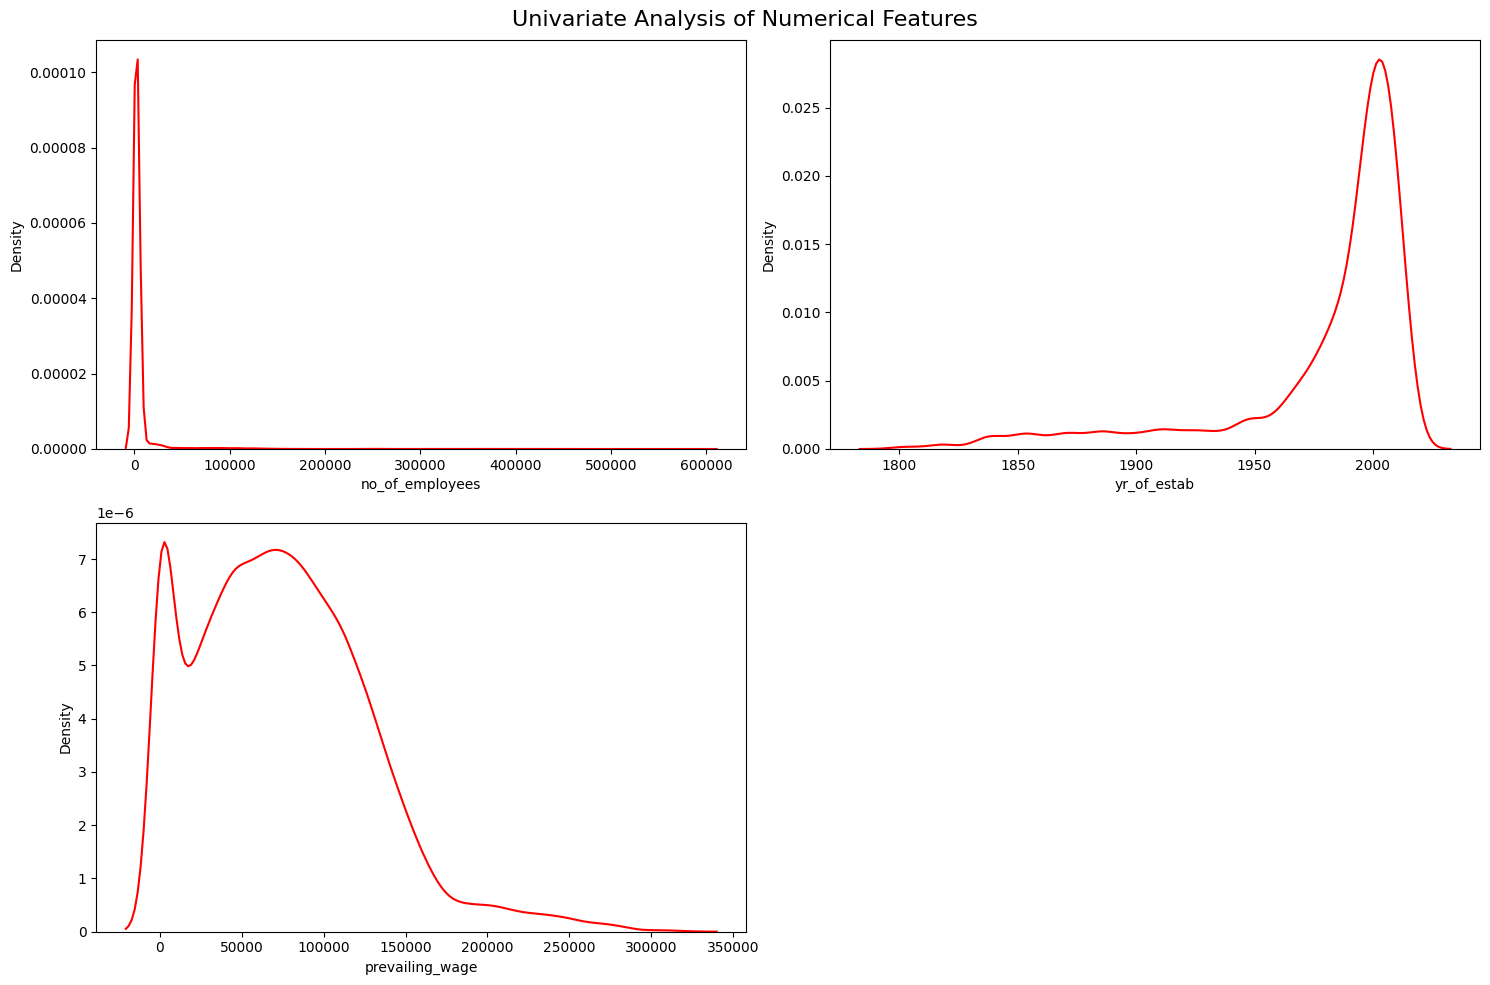

In [38]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=16)

for i in range(0, len(numeric_features)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(df[numeric_features[i]], color='red')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

In [ ]:
'''Insights from Univariate Analysis:'
1) no_of_employees is highly right-skewed → most companies are small, with a few very large organizations acting as outliers.
2) yr_of_estab is left-skewed → most organizations were established between 1990–2010, indicating dominance of relatively modern companies.
3) prevailing_wage shows multiple peaks → suggests different salary groups, possibly representing different job categories or skill levels.
4) no_of_employees and prevailing_wage contain outliers → log transformation or scaling may improve model performance.
5) yr_of_estab can be converted into company age → may provide better business insight and predictive power for ML models.

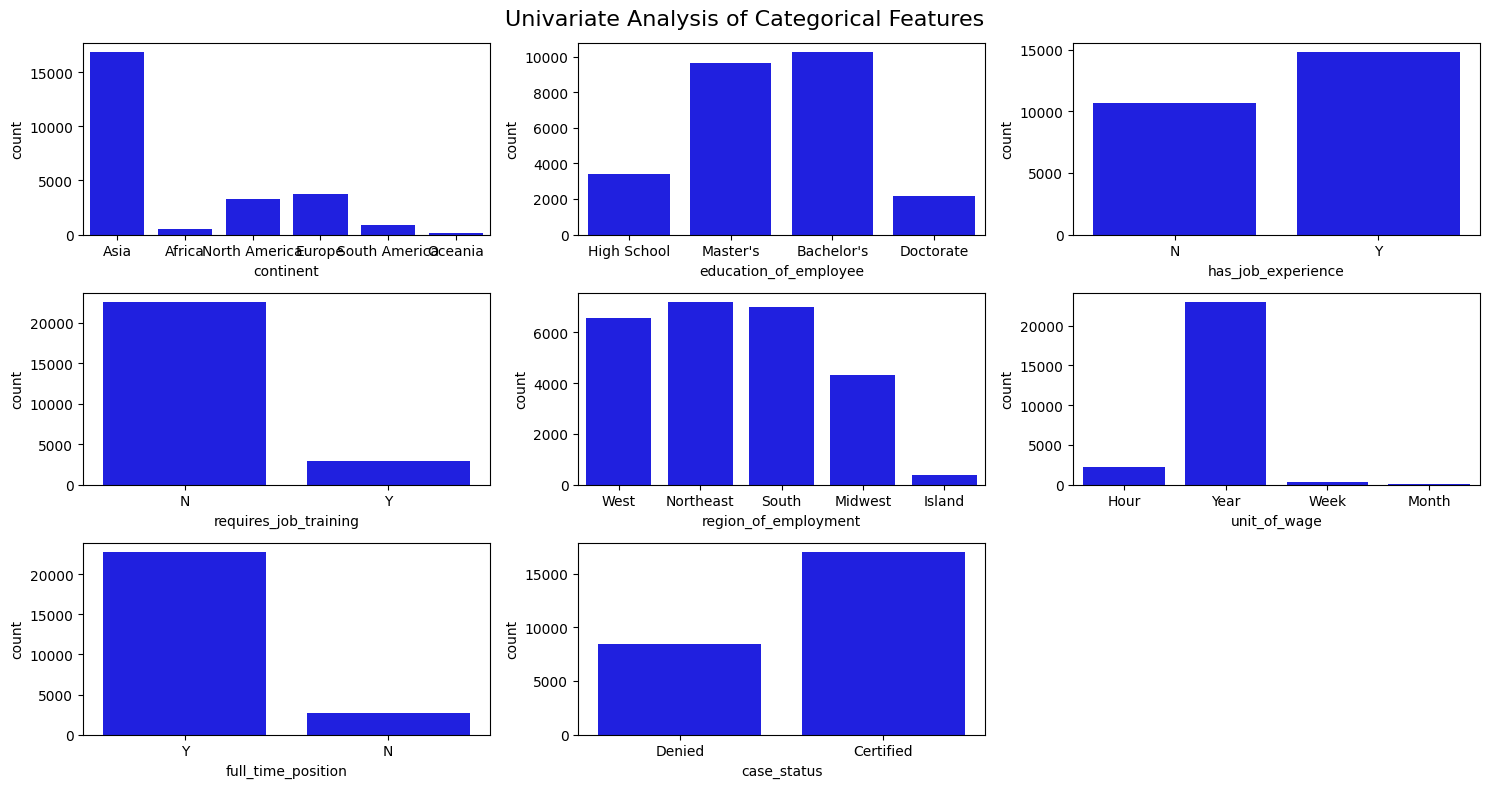

In [40]:
categorical_features.remove('case_id')
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=16)
for i in range(0, len(categorical_features)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[categorical_features[i]], color='blue')
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

Multivariate Analysis

In [42]:
discrete_features=[feature for feature in numeric_features if len(df[feature].unique())<=25]
continuous_features=[feature for feature in numeric_features if len(df[feature].unique())>25]
print("we have {} discrete features : {}".format(len(discrete_features), discrete_features))
print("we have {} continuous features : {}".format(len(continuous_features), continuous_features))


we have 0 discrete features : []
we have 3 continuous features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


In [44]:
from scipy.stats import chi2_contingency
chi2_test = []

for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('reject Null Hypothesis')
    else:
        chi2_test.append('fail to reject Null Hypothesis')

result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']

result

,Column,Hypothesis Result
0,continent,reject Null Hypothesis
1,education_of_employee,reject Null Hypothesis
2,has_job_experience,reject Null Hypothesis
3,requires_job_training,fail to reject Null Hypothesis
4,region_of_employment,reject Null Hypothesis
5,unit_of_wage,reject Null Hypothesis
6,full_time_position,reject Null Hypothesis
7,case_status,reject Null Hypothesis


here requires_job_training fails to reject null hypothesis so it doesnt correlate with target column!

In [45]:
df.isnull().sum()

case_id                   0
continent                 0
education_of_employee    10
has_job_experience        0
requires_job_training     0
no_of_employees           0
yr_of_estab               0
region_of_employment      0
prevailing_wage          30
unit_of_wage              0
full_time_position        0
case_status               0
dtype: int64

In [48]:
continuous_features=[feature for feature in numeric_features if len(df[feature].unique())>=10]
print('No. of continuous features :',continuous_features)

No. of continuous features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


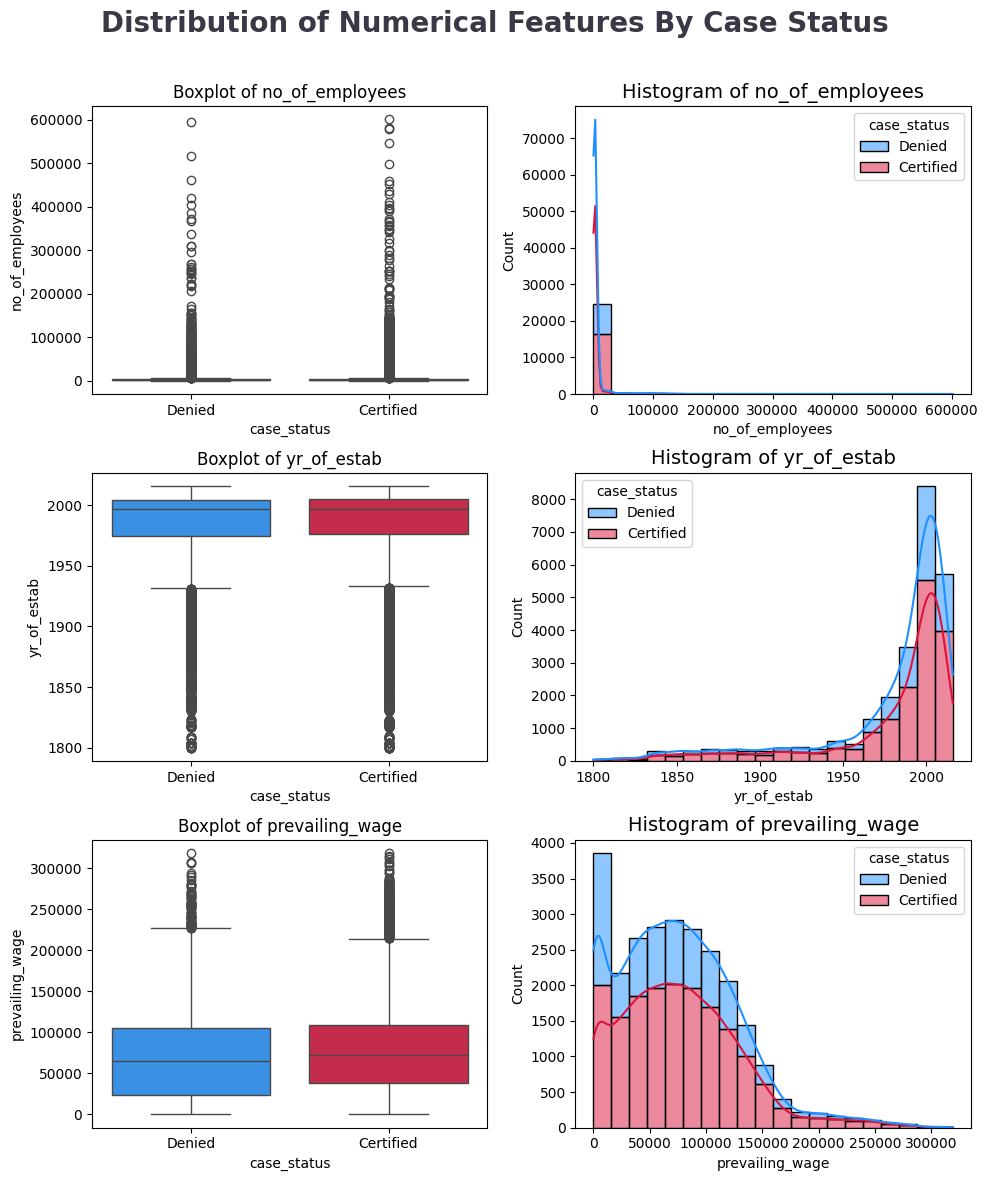

In [50]:
clri = ['#1E90FF', '#DC143C']
fig, ax = plt.subplots(3, 2, figsize=(10,12))
fig.suptitle("Distribution of Numerical Features By Case Status", color='#3C3744',fontsize=20,fontweight='bold',ha='center')
for i, col in enumerate(continuous_features):
    sns.boxplot(
        data=df,
        x='case_status',
        y=col,
        palette=clri,
        ax=ax[i,0]
    )

    ax[i,0].set_title(f'Boxplot of {col}', fontsize=12)

    sns.histplot(
        data=df,
        x=col,
        hue='case_status',
        bins=20,
        kde=True,
        multiple='stack',
        palette=clri,
        ax=ax[i,1]
    )

    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)

fig.tight_layout()
fig.subplots_adjust(top=0.90)